# Multi-Teacher Distillation — Hands-On Demo

> Train 3 diverse teachers on sklearn digits, measure their error decorrelation, distill them into a small student in the semi-supervised transfer-set regime, then stress-test aggregation schemes (uniform / entropy / CA-MKD) with a confidently-wrong corrupted teacher in the pool.

See [multi_teacher_distillation.md](multi_teacher_distillation.md) for the full theory.

Setup: 10-class digits (8x8 images). Teachers train on ~900 labeled samples; the student only has **100 labels + 400 unlabeled** transfer samples — the regime where teacher dark knowledge genuinely adds information beyond the labels. CPU-only, runs in a few minutes.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)
print(torch.__version__)

2.12.0+cu130


## 1. Data

- `X_teach` (897 samples): full labeled set for training teachers
- `X_lab` (100 samples): the student's only labeled data
- `X_unlab` (400 samples): unlabeled transfer set — teachers provide soft targets here
- `X_test` (400 samples): held-out evaluation

This is the classic Hinton transfer-set regime: with only 100 labels, hard-label training is weak, and the teachers' soft targets on the 400 unlabeled samples carry real signal.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0   # [1797, 64], scaled to [0,1]
y = digits.target.astype(np.int64)

X_pool, X_test, y_pool, y_test = train_test_split(X, y, test_size=400, random_state=0, stratify=y)
X_teach, X_stu, y_teach, y_stu = train_test_split(
    X_pool, y_pool, test_size=500, random_state=1, stratify=y_pool)

Xt = torch.from_numpy(X_teach); yt = torch.from_numpy(y_teach)
Xl = torch.from_numpy(X_stu[:100]); yl = torch.from_numpy(y_stu[:100])
Xu = torch.from_numpy(X_stu[100:])                      # unlabeled for the student
yu = torch.from_numpy(y_stu[100:])                      # held back; used ONLY for analysis
Xe = torch.from_numpy(X_test); ye = torch.from_numpy(y_test)
print(f'teachers: {len(Xt)} | student labeled: {len(Xl)} | unlabeled transfer: {len(Xu)} | test: {len(Xe)}')

teachers: 897 | student labeled: 100 | unlabeled transfer: 400 | test: 400


## 2. Train 3 diverse teachers

Diversity sources (weakest to strongest per the report): seed < data subset < architecture. We combine all three so teacher errors decorrelate:

| Teacher | Architecture | Data | Seed |
|---|---|---|---|
| T0 | MLP 64-256-10 (wide) | 60% subset A | 0 |
| T1 | MLP 64-128-128-10 (deep) | 60% subset B | 1 |
| T2 | MLP 64-96-10 + dropout 0.4 | 60% subset C | 2 |

In [3]:
def make_mlp(dims, dropout=0.0, seed=0):
    torch.manual_seed(seed)
    layers = []
    for i in range(len(dims) - 2):
        layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

def train_plain(model, X, y, epochs=60, lr=1e-3, seed=0):
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(len(X), generator=g)
        for i in range(0, len(X), 64):
            idx = perm[i:i+64]
            loss = F.cross_entropy(model(X[idx]), y[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    return model

@torch.no_grad()
def accuracy(model, X, y):
    model.eval()
    return (model(X).argmax(-1) == y).float().mean().item()

@torch.no_grad()
def logits_of(model, X):
    model.eval()
    return model(X)

specs = [dict(dims=[64, 256, 10], dropout=0.0),
         dict(dims=[64, 128, 128, 10], dropout=0.0),
         dict(dims=[64, 96, 10], dropout=0.4)]
teachers = []
for k, spec in enumerate(specs):
    rng = np.random.RandomState(k)
    sub = rng.choice(len(Xt), size=int(0.6 * len(Xt)), replace=False)
    m = make_mlp(spec['dims'], spec['dropout'], seed=k)
    train_plain(m, Xt[sub], yt[sub], epochs=60, seed=k)
    teachers.append(m)
    print(f'T{k}: test acc = {accuracy(m, Xe, ye):.4f}')

T0: test acc = 0.9475


T1: test acc = 0.9525


T2: test acc = 0.9350


## 3. Are the teachers actually diverse?

The report's rule: **measure error correlation before adding teachers**. We compute each teacher's error vector on the test set, the pairwise error correlation and prediction disagreement rate, and the uniform-logit ensemble accuracy — the ceiling MTKD tries to compress into one model.

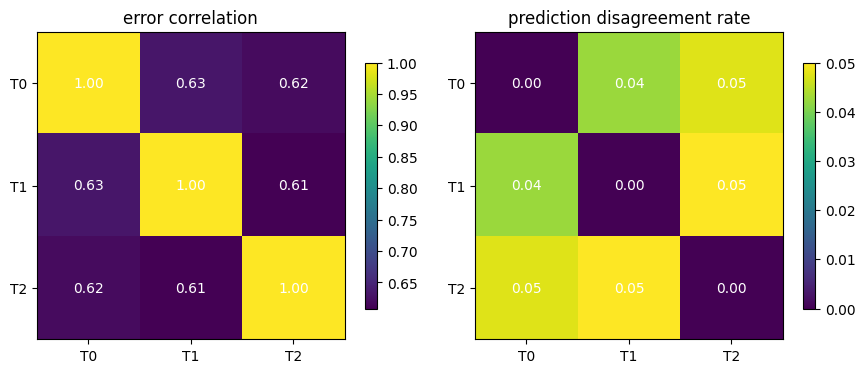

T0 test acc = 0.9475
T1 test acc = 0.9525
T2 test acc = 0.9350
uniform-logit ENSEMBLE test acc = 0.9525  <- ceiling to compress


In [4]:
T_logits_test = torch.stack([logits_of(m, Xe) for m in teachers])   # [K, N, C]
preds = T_logits_test.argmax(-1)
errors = (preds != ye).float()

K = len(teachers)
err_corr = np.ones((K, K)); disagree = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if i != j:
            err_corr[i, j] = np.corrcoef(errors[i].numpy(), errors[j].numpy())[0, 1]
            disagree[i, j] = (preds[i] != preds[j]).float().mean().item()

ens_acc = (T_logits_test.mean(0).argmax(-1) == ye).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, M, title in [(axes[0], err_corr, 'error correlation'),
                     (axes[1], disagree, 'prediction disagreement rate')]:
    im = ax.imshow(M, cmap='viridis')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels([f'T{k}' for k in range(K)])
    ax.set_yticklabels([f'T{k}' for k in range(K)])
    ax.set_title(title)
    for a in range(K):
        for b in range(K):
            ax.text(b, a, f'{M[a, b]:.2f}', ha='center', va='center', color='w')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

for k in range(K):
    print(f'T{k} test acc = {accuracy(teachers[k], Xe, ye):.4f}')
print(f'uniform-logit ENSEMBLE test acc = {ens_acc:.4f}  <- ceiling to compress')

## 4. Semi-supervised MTKD: 4 students compared

All students share the same small architecture (64-48-10). Teacher logits on the unlabeled set are **precomputed offline once** (recipe step 1 in the report) — training then costs the same per step as single-teacher KD.

Loss per step: cross-entropy on a labeled mini-batch (100 samples available) + $T^2 \sum_k w_k\,\mathrm{KL}$ on an unlabeled mini-batch.

1. **Scratch** — 100 hard labels only
2. **Best single teacher** — vanilla KD from the highest-accuracy teacher
3. **Uniform MTKD** — all teachers, $w_k = 1/K$
4. **Entropy-weighted (EBKD-style)** — trust the locally-confident teacher; label-free, so it works on unlabeled data (CA-MKD needs labels — it appears in Section 5)

In [5]:
def kd_term(logits, targets, w, T):
    # logits [B,C]; targets [K,B,C] teacher logits; w [K,B] weights summing to 1 over K
    log_p_s = F.log_softmax(logits / T, dim=-1)
    q = F.softmax(targets / T, dim=-1)
    kl = (q * (q.clamp_min(1e-9).log() - log_p_s)).sum(-1)   # [K, B]
    return (w * kl).mean(dim=1).sum()

def train_semi(model, Xl, yl, Xu, kd_targets, kd_weights=None, epochs=150, lr=1e-3,
               T=4.0, seed=0):
    # CE on the labeled set + KD on the unlabeled transfer set
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Kn = kd_targets.shape[0]
    for ep in range(epochs):
        perm = torch.randperm(len(Xu), generator=g)
        for i in range(0, len(Xu), 64):
            idx = perm[i:i+64]
            lidx = torch.randint(0, len(Xl), (32,), generator=g)
            w = (torch.full((Kn, len(idx)), 1.0 / Kn) if kd_weights is None
                 else kd_weights[:, idx])
            loss = F.cross_entropy(model(Xl[lidx]), yl[lidx]) \
                + (T ** 2) * kd_term(model(Xu[idx]), kd_targets[:, idx], w, T)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

T_KD = 4.0
T_logits_u = torch.stack([logits_of(m, Xu) for m in teachers])   # [K, 400, C] precomputed

# EBKD-style weights: softmax over negative teacher entropy, per sample (label-free)
q_u = F.softmax(T_logits_u / T_KD, dim=-1)
H = -(q_u * q_u.clamp_min(1e-9).log()).sum(-1)   # [K, N]
w_entropy = F.softmax(-H, dim=0)

best_k = int(np.argmax([accuracy(m, Xe, ye) for m in teachers]))
print(f'best single teacher: T{best_k}')

settings = {
    'scratch (100 labels)': (None, None),
    f'single best (T{best_k})': (T_logits_u[best_k:best_k+1], None),
    'uniform MTKD': (T_logits_u, None),
    'entropy MTKD': (T_logits_u, w_entropy),
}

N_SEEDS = 3
results = {}
for name, (tg, w) in settings.items():
    accs = []
    for seed in range(N_SEEDS):
        s = make_mlp([64, 48, 10], seed=100 + seed)
        if tg is None:
            train_plain(s, Xl, yl, epochs=300, seed=200 + seed)
        else:
            train_semi(s, Xl, yl, Xu, tg, w, epochs=150, T=T_KD, seed=200 + seed)
        accs.append(accuracy(s, Xe, ye))
    results[name] = (np.mean(accs), np.std(accs))
    print(f'{name:22s}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

best single teacher: T1


scratch (100 labels)  : 0.8892 +/- 0.0012


single best (T1)      : 0.9458 +/- 0.0012


uniform MTKD          : 0.9467 +/- 0.0012


entropy MTKD          : 0.9483 +/- 0.0024


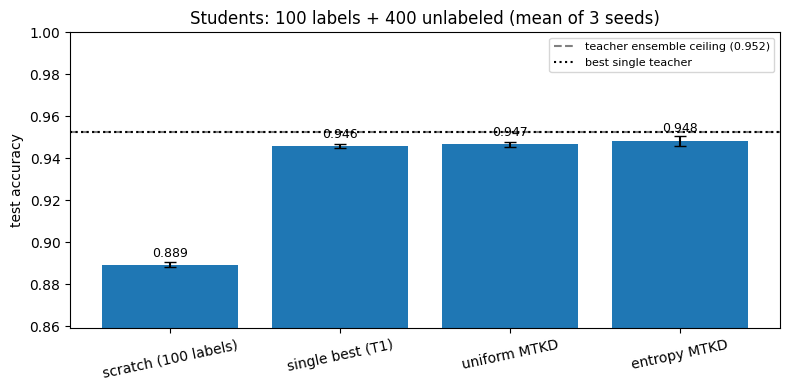

In [6]:
names = list(results.keys())
means = [results[n][0] for n in names]
stds = [results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, means, yerr=stds, capsize=4)
ax.axhline(ens_acc, ls='--', color='gray', label=f'teacher ensemble ceiling ({ens_acc:.3f})')
ax.axhline(max(accuracy(m, Xe, ye) for m in teachers), ls=':', color='black',
           label='best single teacher')
ax.set_ylim(min(means) - 0.03, 1.0)
ax.set_ylabel('test accuracy')
ax.set_title(f'Students: 100 labels + 400 unlabeled (mean of {N_SEEDS} seeds)')
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.004, f'{m:.3f}', ha='center', fontsize=9)
ax.legend(fontsize=8)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

## 5. Stress test: a confidently-wrong teacher in the pool

The report's Section 5 failure-mode analysis, reproduced. We build a **corrupted teacher**: trained on the full teacher set but with labels systematically swapped (1 <-> 7, 3 <-> 8 — plausible digit confusions). It is *confident* everywhere, *wrong* on 4 of 10 classes.

Because student-side accuracy differences drown in training noise on this small benchmark, we evaluate the **aggregated soft target directly** (deterministic — no training in the loop): the accuracy of $\mathrm{argmax}\,\sum_k w_k(x)\, q^{(k)}(x)$ on the transfer set, overall and split into swapped vs clean classes, for each weighting scheme:

- **uniform**: bad teacher pollutes swapped classes, helps clean ones
- **entropy (EBKD)**: cannot detect the bad teacher — it is confident when wrong
- **CA-MKD**: uses the ground-truth label, so it excises the bad teacher exactly where it is wrong

In [7]:
SWAP = {1: 7, 7: 1, 3: 8, 8: 3}
y_corrupt = yt.clone()
for a, b in SWAP.items():
    y_corrupt[yt == a] = b
bad = make_mlp([64, 128, 10], seed=9)
train_plain(bad, Xt, y_corrupt, epochs=60, seed=9)
print(f'corrupted teacher test acc: {accuracy(bad, Xe, ye):.3f} (wrong on classes 1,3,7,8)')

pool4 = teachers + [bad]
Tl4 = torch.stack([logits_of(m, Xu) for m in pool4])       # [4, 400, C]
q4 = F.softmax(Tl4 / T_KD, dim=-1)

# entropy weights (label-free)
H4 = -(q4 * q4.clamp_min(1e-9).log()).sum(-1)
w_ent4 = F.softmax(-H4, dim=0)

# CA-MKD weights (need labels; yu is used here, playing the role of a labeled transfer set)
ce4 = torch.stack([F.cross_entropy(Tl4[k], yu, reduction='none') for k in range(4)])
w_conf4 = F.softmax(-ce4, dim=0)

swapped = torch.isin(yu, torch.tensor(sorted(SWAP)))
print(f'swapped-class samples in transfer set: {int(swapped.sum())}/{len(yu)}')

def target_quality(w):
    tgt = (w.unsqueeze(-1) * q4[:w.shape[0]]).sum(0)
    correct = (tgt.argmax(-1) == yu).float()
    return correct.mean().item(), correct[swapped].mean().item(), correct[~swapped].mean().item()

schemes = {
    'uniform-3T (no bad)': torch.full((3, len(yu)), 1 / 3),
    'uniform-4T (+bad)': torch.full((4, len(yu)), 1 / 4),
    'entropy-4T (+bad)': w_ent4,
    'CA-MKD-4T (+bad)': w_conf4,
}
quality = {name: target_quality(w) for name, w in schemes.items()}
for name, (a, s, c) in quality.items():
    print(f'{name:20s} target acc: all={a:.3f}  swapped={s:.3f}  clean={c:.3f}')

corrupted teacher test acc: 0.575 (wrong on classes 1,3,7,8)
swapped-class samples in transfer set: 157/400
uniform-3T (no bad)  target acc: all=0.955  swapped=0.949  clean=0.959
uniform-4T (+bad)    target acc: all=0.952  swapped=0.924  clean=0.971
entropy-4T (+bad)    target acc: all=0.957  swapped=0.936  clean=0.971
CA-MKD-4T (+bad)     target acc: all=0.973  swapped=0.962  clean=0.979


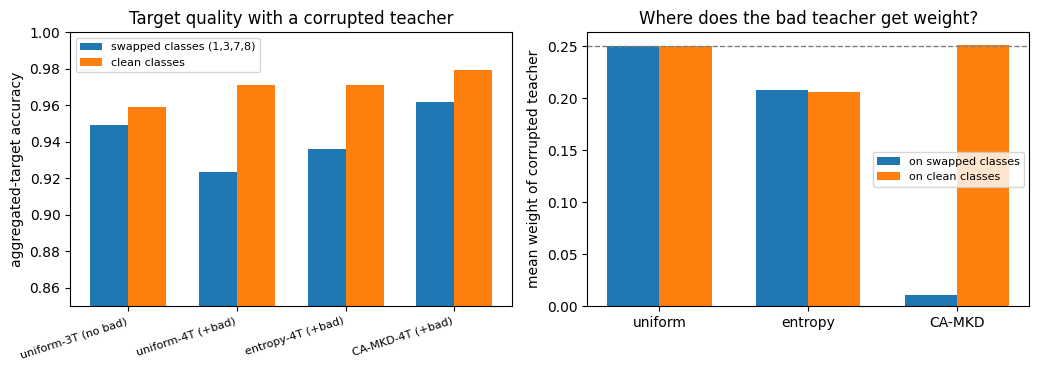

entropy weight of bad teacher: swapped=0.208 vs clean=0.205 (blind)
CA-MKD  weight of bad teacher: swapped=0.011 vs clean=0.251 (surgical)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

# left: aggregated-target accuracy by class group
names = list(quality.keys())
x = np.arange(len(names)); width = 0.35
sw = [quality[n][1] for n in names]
cl = [quality[n][2] for n in names]
axes[0].bar(x - width / 2, sw, width, label='swapped classes (1,3,7,8)')
axes[0].bar(x + width / 2, cl, width, label='clean classes')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=18, ha='right', fontsize=8)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel('aggregated-target accuracy')
axes[0].set_title('Target quality with a corrupted teacher')
axes[0].legend(fontsize=8)

# right: how much weight each scheme gives the corrupted teacher
w_bad = {
    'uniform': (0.25, 0.25),
    'entropy': (w_ent4[3][swapped].mean().item(), w_ent4[3][~swapped].mean().item()),
    'CA-MKD': (w_conf4[3][swapped].mean().item(), w_conf4[3][~swapped].mean().item()),
}
x2 = np.arange(len(w_bad))
axes[1].bar(x2 - width / 2, [v[0] for v in w_bad.values()], width, label='on swapped classes')
axes[1].bar(x2 + width / 2, [v[1] for v in w_bad.values()], width, label='on clean classes')
axes[1].axhline(0.25, ls='--', color='gray', lw=1)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(list(w_bad.keys()))
axes[1].set_ylabel('mean weight of corrupted teacher')
axes[1].set_title('Where does the bad teacher get weight?')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"entropy weight of bad teacher: swapped={w_bad['entropy'][0]:.3f} vs clean={w_bad['entropy'][1]:.3f} (blind)")
print(f"CA-MKD  weight of bad teacher: swapped={w_bad['CA-MKD'][0]:.3f} vs clean={w_bad['CA-MKD'][1]:.3f} (surgical)")

Three things worth staring at:

1. **Uniform averaging degrades exactly where the bad teacher is wrong** (swapped classes) and *improves* on clean classes — a weak teacher still contributes where it happens to be right.
2. **Entropy weighting gives the corrupted teacher the same weight on swapped and clean classes** — confidence cannot distinguish justified from miscalibrated certainty. This is the report's EBKD failure mode, verbatim.
3. **CA-MKD is surgical**: near-zero weight where the teacher is wrong, full 1/K weight where it is right — so its target beats even the clean 3-teacher pool.

## 6. Negative control: a redundant teacher pool

The report's key insight: **the value is in error decorrelation, not head count**. We clone teacher T0 three times (identical weights) and re-run uniform MTKD — it should match single-teacher KD from T0 exactly, proving head count alone adds nothing.

In [9]:
T0_logits = T_logits_u[0]
clone_stack = torch.stack([T0_logits, T0_logits, T0_logits])

accs_clone, accs_single = [], []
for seed in range(N_SEEDS):
    s1 = make_mlp([64, 48, 10], seed=300 + seed)
    train_semi(s1, Xl, yl, Xu, clone_stack, epochs=150, T=T_KD, seed=400 + seed)
    accs_clone.append(accuracy(s1, Xe, ye))
    s2 = make_mlp([64, 48, 10], seed=300 + seed)
    train_semi(s2, Xl, yl, Xu, T0_logits.unsqueeze(0), epochs=150, T=T_KD, seed=400 + seed)
    accs_single.append(accuracy(s2, Xe, ye))

print(f'3x cloned T0 (uniform MTKD): {np.mean(accs_clone):.4f} +/- {np.std(accs_clone):.4f}')
print(f'single T0 KD               : {np.mean(accs_single):.4f} +/- {np.std(accs_single):.4f}')
print(f'diverse 3-teacher MTKD     : {results["uniform MTKD"][0]:.4f} (from Section 4)')
gap = abs(np.mean(accs_clone) - np.mean(accs_single))
print(f'\nclone-pool vs single-teacher gap: {gap:.4f} (identical teachers add nothing)')

3x cloned T0 (uniform MTKD): 0.9358 +/- 0.0031
single T0 KD               : 0.9358 +/- 0.0031
diverse 3-teacher MTKD     : 0.9467 (from Section 4)

clone-pool vs single-teacher gap: 0.0000 (identical teachers add nothing)


## Takeaways

1. **The transfer-set regime is where distillation earns its keep**: with only 100 labels, scratch training plateaus far below the teachers; adding teacher soft targets on 400 unlabeled samples recovers most of the gap to the ensemble ceiling. (In an early version of this notebook the students had *all 400 labels* — and KD then lost to scratch, because perfect labels leave soft targets nothing to add. Regime choice is not a detail.)
2. **Diverse teachers decorrelate errors** — different architecture + data subset + seed gave low error correlation, so the uniform-logit ensemble beats every individual teacher, and multi-teacher students edge out the single-best-teacher student.
3. **Entropy weighting is blind to confidently-wrong teachers**: the corrupted teacher got the same weight on classes it fails as on classes it masters. CA-MKD, which checks teachers against ground truth per sample, removed it surgically — and its aggregated target beat even the clean 3-teacher pool, because the bad teacher still helps where it is right.
4. **Head count without diversity is decorative** — three cloned copies of one teacher matched that single teacher exactly; the gain comes from error decorrelation, not from more KL terms.
5. Teacher logits were **precomputed offline once**, so MTKD training cost the same per step as single-teacher KD (the report's recipe step 1).